In [2]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import warnings
from mlxtend.plotting import plot_decision_regions
from matplotlib.colors import ListedColormap
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import Dropout
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.model_selection import train_test_split
from sklearn.datasets import make_circles
import seaborn as sns


In [3]:
X, y = make_circles(n_samples=1000, noise=0.1, random_state=42)

<Axes: >

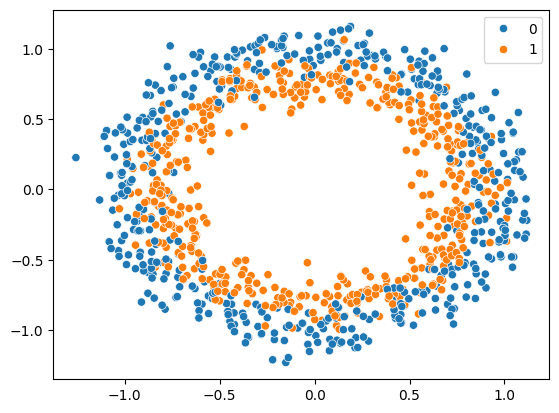

In [4]:
sns.scatterplot(x=X[:, 0], y=X[:, 1], hue=y)

In [5]:
x_train, x_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [6]:
model=Sequential()

model.add(Dense(256, input_dim=2, activation='relu'))
model.add(Dense(1, activation='sigmoid'))

In [7]:
model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])


In [8]:
history = model.fit(x_train, y_train, validation_data=(x_test, y_test), epochs=3500, batch_size=32, verbose=0)

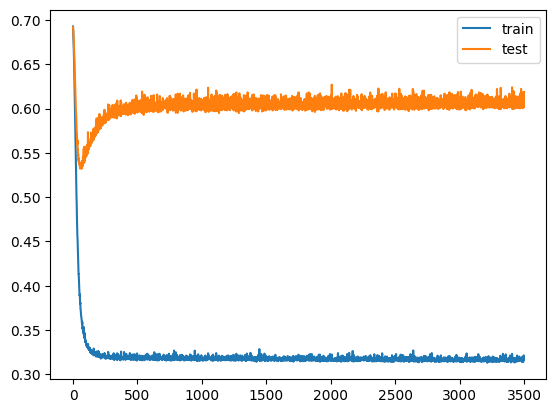

In [9]:
plt.plot(history.history['loss'], label='train')
plt.plot(history.history['val_loss'], label='test')
plt.legend()
plt.show()

9600/9600 [==============================] - 23s 2ms/step


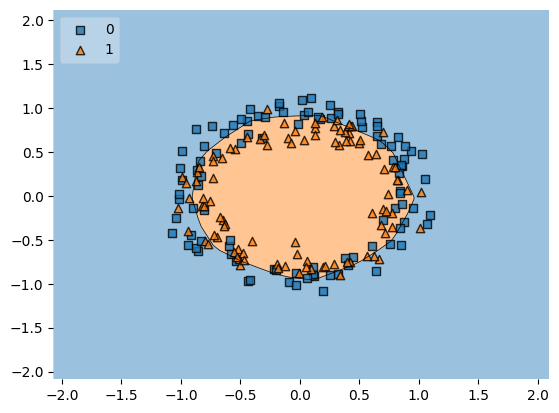

In [12]:
plot_decision_regions(x_test, y_test.ravel(), clf=model, legend=2)
plt.show()

# early stopping

In [13]:
model=Sequential()

model.add(Dense(256, input_dim=2, activation='relu'))
model.add(Dense(1, activation='sigmoid'))

In [14]:
model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])


In [15]:
callback=EarlyStopping(monitor='val_loss', patience=20, restore_best_weights=False,verbose=1,min_delta=0.0001,mode="auto",baseline=None)

In [16]:
history = model.fit(x_train, y_train, validation_data=(x_test, y_test), epochs=3500,  verbose=0, callbacks=[callback])

Epoch 76: early stopping


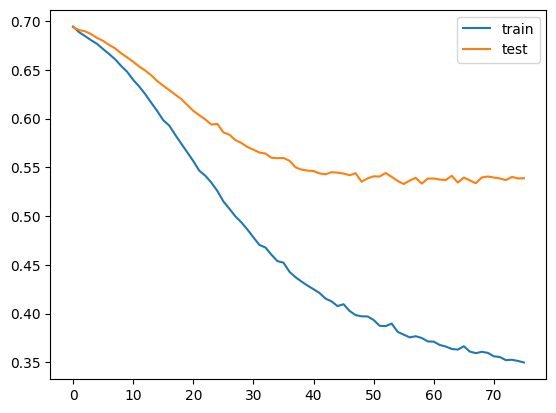

In [17]:
plt.plot(history.history['loss'], label='train')
plt.plot(history.history['val_loss'], label='test')
plt.legend()
plt.show()

9600/9600 [==============================] - 19s 2ms/step


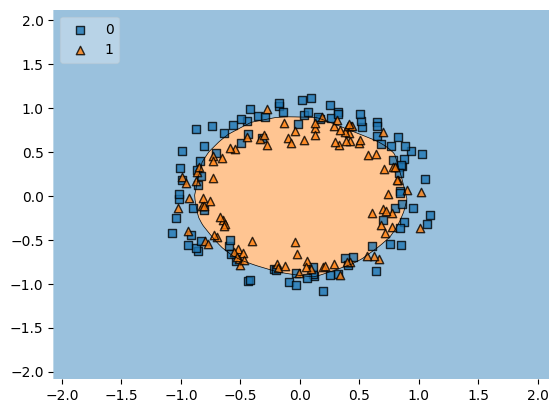

In [21]:
plot_decision_regions(x_test, y_test.ravel(), clf=model, legend=2)
plt.show()